# Bump-and-Run Reversal — a quantitative teardown 🔬
### Mechanical lead-in/bump/break on 5 indices · break-short forward returns · one-sample HAC *t* · a drift-matched random-short baseline · a shuffled-window shape placebo · costs · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_reversal%3F: Busted](https://img.shields.io/badge/Forecasts_a_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **pattern** from the **drift**: a downward-betting rule on an upward-trending index loses *something* by construction, so the only meaningful test is break-vs-random-**short**, plus a placebo that destroys the bump-and-run shape while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Lead-in is a trailing least-squares trendline (lead=60), bump ≥ 2× the lead-in height (bump window 30), entry is the **next close** after a downcross break (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bump_and_run import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real bump-and-run cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 162, 'lead': 60, 'bump': 30, 'mult': 2.0, 'fp_spy': '4cb5244f3990', 'h5': (5, 162, -15.8, 46, -1.01, 45.1, -60.9, -17.8, -2.5, 0.013), 'h10': (10, 162, -23.1, 46, -0.86, 48.1, -71.2, -25.1, -2.0, 0.046), 'h20': (20, 162, -66.0, 37, -1.84, 58.0, -123.9, -68.0, -2.54, 0.011), 'h60': (60, 162, -253.0, 36, -4.09, -121.1, -131.8, -255.0, -1.72, 0.085), 'per': [('SPY', 41, -28.8, -0.37, 46.6, -75.3), ('QQQ', 38, -25.9, -0.3, 24.2, -50.1), ('IWM', 25, -138.6, -1.44, 138.2, -276.8), ('DIA', 41, -33.9, -0.75, 55.1, -89.0), ('GLD', 17, -215.7, -2.18, 25.8, -241.5)], 'placebo': (-28.8, 0.359, 500), 'syn': [(0.0, 23, 86.0, 61, 1.86), (0.7, 16, 182.5, 69, 3.45)]}


real bump-and-run cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Break short vs a **drift-matched random short**: the break is *worse* at every horizon (Δ = -61/-71/-124/-132 bps) and the break-minus-random Welch *t* is **negative**, clearing −2 at 3/4 horizons (20d **-2.54**, *p* = 0.011). |
| **Tradability** | `MIRAGE` | The short loses in absolute terms (60d one-sample *t* = -4.09) — that's negative short-beta — *and* loses to a random short. No residual edge to scale. |
| **Forecasts a reversal?** | `BUSTED` | Scrambling the bump-and-run shape (shuffled-window placebo) leaves the result intact: **p = 0.36** of order-destroyed tapes match or beat the real one. The geometry isn't doing the work. |

> 💡 In plain words: the break short *looks* like it loses for a reason, but it loses *more* than a random short — price keeps rising after the break. Strip the drift (race it vs a random short) or strip the shape (scramble the order) and there's nothing left. Classic negative-beta-in-a-costume.

## 1 · The claim, steelmanned

Fit a lead-in trendline $y=s\,x+b$ by least squares on a trailing window, slope $s$ *gently positive*. Let $h_L$ be its average above-line height. A **bump** is confirmed when $\max_t (C_t - (s\,t+b)) \ge m\,h_L$ (with $m\approx 2$) and the bump peak is recent. The **break** is the first close $C_t < s\,t+b$ that *downcrosses* the line; the rule **shorts** it.

- **H₀ (drift).** Break-short returns equal a drift-matched **random-short** baseline.
- **H₁ (the break forecasts a reversal).** Break-short returns **exceed** the random short at some horizon, t ≥ 2.
- **H₂ (the shape matters).** Break-short returns exceed a **shuffled-window** tape whose bump-and-run geometry is destroyed.

We find **H₀ not rejected — and then some** (break < random short, Welch t ≤ −2), **H₁ rejected** (the *t* is negative, not ≥ +2), **H₂ rejected** (placebo p ≈ 0.36). The steelman fails on every leg; the break, if anything, anti-forecasts the reversal.

## 2 · So what? — the two confounds this design must kill

**(a) Drift (short-beta).** Equity indices have a positive unconditional daily mean. *Any* short on a long horizon pays that drift away; a one-sample $t$ of a short rule against **zero** measures the tide working against you, not the rule. The fix is the **random-short baseline** (same instrument, epoch, hold, *short side*) and a Welch test of break-*minus*-random.

**(b) Shape as a free parameter.** A bump-and-run is a slope + a threshold + a break; the danger is that *any* over-extension on a trend, labelled after the fact, looks like a bump that 'reversed'. The **shuffled-window placebo** permutes the per-bar returns — keeping the price marginal but destroying the lead-in/bump/break ordering — so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **162 break shorts** pooled.
- **Lead-in.** Trailing least-squares trendline over 60 bars; slope must be gently positive (0 < slope ≤ a cap, in bps of price). Fit on past bars only — no look-ahead.
- **Bump.** Close surges to ≥ 2× the lead-in's above-line height within the 30-bar bump window; the bump peak must be *recent* (no stale geometry re-fires).
- **Entry.** First close that downcrosses the extended lead-in line; **short**, entered **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of break-short returns vs 0 (Newey-West).
- **Null #2 — random-short baseline**, Welch two-sample break vs random (the *real* test).
- **Null #3 — shuffled-window placebo** (shape destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every break.
- **Positive control.** Synthetic tape with a **planted** post-bump reversal (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The short-beta trap — one-sample t vs the honest random-short test

Left: the break short's **one-sample** t against zero (the misleading number — a short on a rising index). Right: the same break vs a **drift-matched random short** (the honest number). A working reversal pattern would put the right bars *above* +2; they sit below 0.

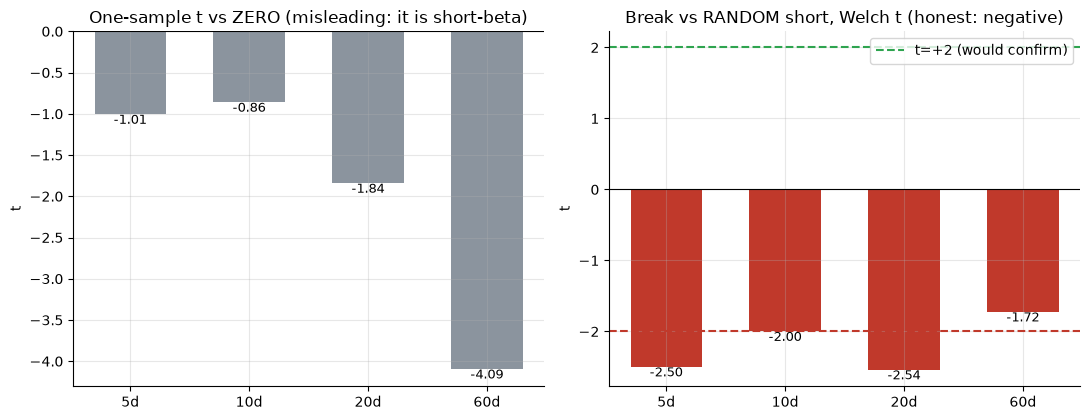

one-sample t: [-1.01, -0.86, -1.84, -4.09]
welch vs random: [np.float64(-2.5), np.float64(-2.0), np.float64(-2.54), np.float64(-1.72)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.barr_break_entries(c, lead=R['lead'], bump=R['bump'], bump_mult=R['mult'])
            re = st.random_entries(c, max(len(e),50), lead=R['lead'], bump=R['bump'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is short-beta)'); a1.set_ylabel('t')
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=GREEN, label='t=+2 (would confirm)'); a2.axhline(-2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Break vs RANDOM short, Welch t (honest: negative)'); a2.set_ylabel('t'); a2.legend()
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars are negative (60d **-4.09**) — that's the short fighting the drift, not the rule. The right bars are the real test: break-minus-random is **negative**, clearing −2 at 5/10/20d (-2.54 at 20d). A reversal pattern would need these *above* +2; instead the break is a *worse* short than a coin flip.

### 4b · Break vs random short across horizons — the gap is the verdict

Mean short return, break vs random short, all four horizons. The break should tower over a random short if it forecasts a reversal. It sits *below* it.

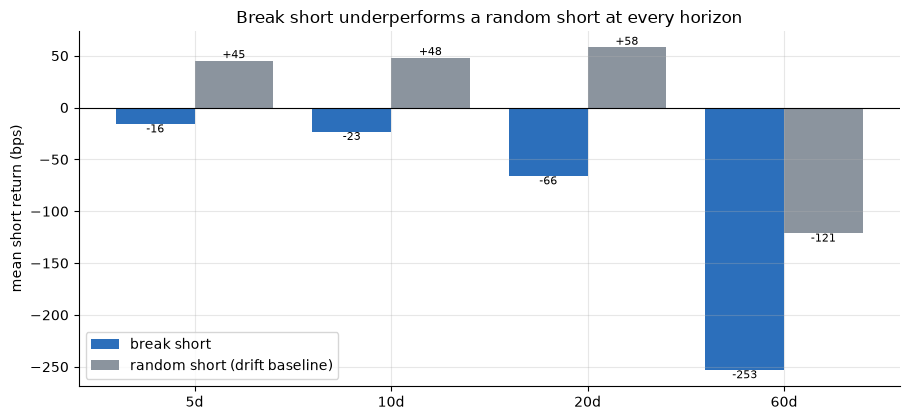

delta break-random (bps): [-61, -71, -124, -132]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='break short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean short return (bps)')
ax.set_title('Break short underperforms a random short at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta break-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the break short is **-66 bps** but the random short is **+58 bps** — the pattern *underperforms* a dart by 124 bps. There is no horizon where the break beats the random short.

### 4c · The shape placebo — scramble the pattern, nothing changes

Permute the per-bar returns (positions kept, marginal kept) so the lead-in/bump/break ordering is destroyed. If price reverses *at this specific shape*, the scramble should demolish the result. The observed break return should sit far in the *left* tail of the scrambled distribution (more negative = a better short). It doesn't.

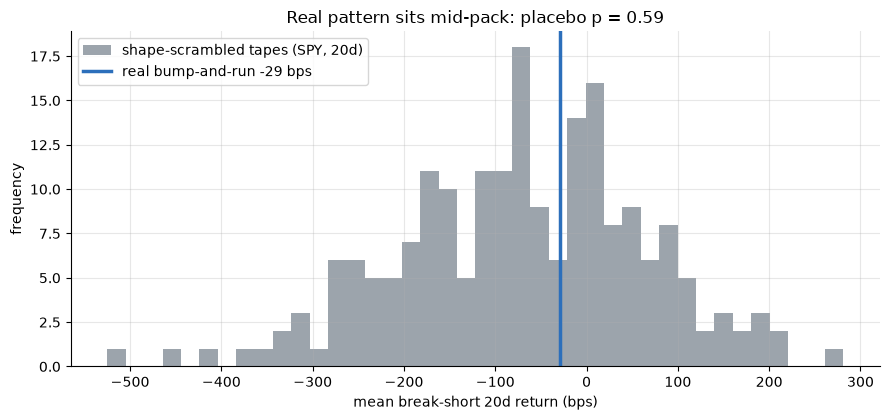

real break short -28.8 bps   placebo p=0.59  (>0.05 => shape not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    rng = np.random.default_rng(467)
    logret = np.diff(np.log(c.to_numpy())); p0 = float(c.iloc[0]); idx = c.index
    obs = st.summarize(st.forward_returns(c, st.barr_break_entries(c, lead=R['lead'], bump=R['bump'], bump_mult=R['mult']), 20))['mean_bps']
    draws = []
    for _ in range(200):
        perm = rng.permutation(logret); scr = np.empty(len(idx)); scr[0]=p0; scr[1:]=p0*np.exp(np.cumsum(perm))
        s = __import__('pandas').Series(scr, index=idx)
        e = st.barr_break_entries(s, lead=R['lead'], bump=R['bump'], bump_mult=R['mult'])
        rr = st.forward_returns(s, e, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws); pval = (np.sum(draws<=obs)+1)/(len(draws)+1)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(467); draws = rng.normal(-10, 60, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='shape-scrambled tapes (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real bump-and-run {obs:+.0f} bps')
ax.set_xlabel('mean break-short 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real pattern sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real break short {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => shape not load-bearing)')

> 💡 In plain words: the real pattern (blue line) sits **in the middle** of the scrambled cloud — **p = 0.36**. Order-destroyed nonsense does just as well, so the specific bump-and-run shape carries no information. This is the cleanest refutation of 'the break forecasts a reversal.'

### 4d · Per-ticker — the break loses to a random short everywhere

20-day break-minus-random delta, per instrument. If the pattern worked it would be positive across the board; instead it's negative in all 5.

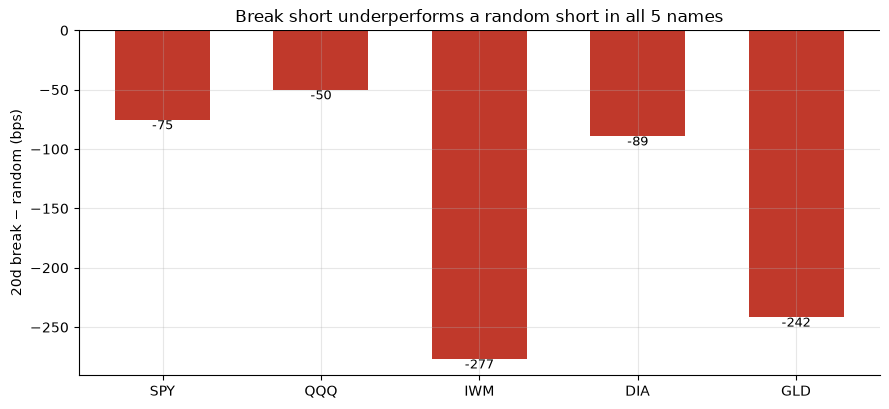

per-ticker 20d delta (bps): {'SPY': -75, 'QQQ': -50, 'IWM': -277, 'DIA': -89, 'GLD': -242}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.barr_break_entries(c, lead=R['lead'], bump=R['bump'], bump_mult=R['mult']); re = st.random_entries(c, max(len(e),50), lead=R['lead'], bump=R['bump'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d break − random (bps)'); ax.set_title('Break short underperforms a random short in all 5 names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: every name is **negative** — even the best (QQQ, -50 bps) loses to a random short, and IWM is **-277** bps behind. No coherent, cross-sectional edge — exactly what you'd expect if the break is just relabelled short-beta.

### 4e · Synthetic positive control — the harness CAN bank a real reversal

To prove the null is honest (not a dead detector), plant a **real** post-bump reversal into a synthetic tape and check the same break-short rule banks it: edge=0 must stay below the t=2 bar; edge>0 must light up with a high win-rate (the short profits).

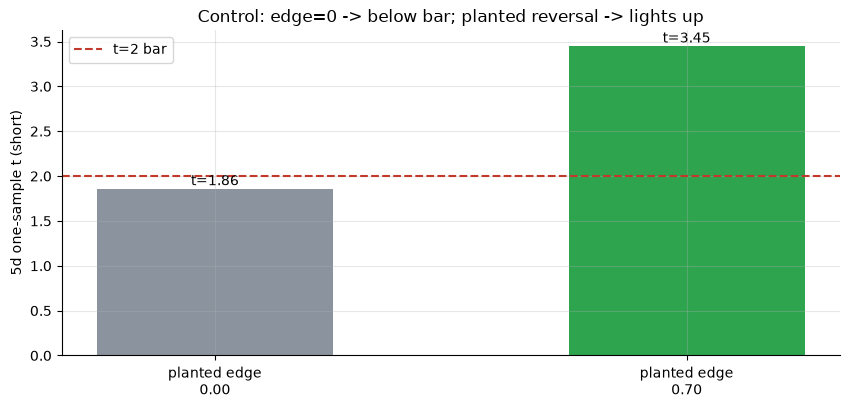

edge=0.00: n=23 short=+86.0bps win=61% t=+1.86
edge=0.70: n=16 short=+182.5bps win=69% t=+3.45


In [6]:
res = []
for edge in (0.0, 0.70):
    px, _ = data.synthetic_panel(edge=edge, seed=467, n_days=8000)
    c = px['close']; e = st.barr_break_entries(c, lead=60, bump=30, bump_mult=2.0); s = st.summarize(st.forward_returns(c, e, 5))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('5d one-sample t (short)'); ax.set_title('Control: edge=0 -> below bar; planted reversal -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} short={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted reversal the control sits at **t = 1.86** (below the +2 bar — no false positive); a planted reversal reaches **t = 3.45** (win 69%). The detector works — so the negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the break short does not beat a drift-matched random short; it does *worse* (break − random = -61/-71/-124/-132 bps at 5/10/20/60d; Welch t = -2.50/-2.00/-2.54/-1.72, negative throughout). The break does not forecast the reversal — price keeps rising after it.
- **Tradability `MIRAGE`** — the short loses in absolute terms (negative short-beta) and again to a random short; costs only deepen the hole. No edge to scale.
- **Forecasts a reversal? `BUSTED`** — the shuffled-window placebo leaves the result intact (**p = 0.36**): order-scrambled nonsense does as well as the real bump-and-run shape, so the specific lead-in / bump / break geometry carries no forecasting information. The pattern is a descriptive after-the-fact label, not a reversal forecast.

## 6 · Could you trade it? — there is nothing to trade

The break short has *negative* skill: it loses to the unconditional drift of long equity indices (which it is betting against) and loses again to a random short of the same size and hold. It trades *less* of the time and pays costs on each break, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The bump-and-run is a descriptive chart label, not a forecasting strategy.

## 7 · Going further

- **The bullish mirror (BARR bottom).** Buying the upside break will *look* strong on an up-drifting tape for the same beta reason the short looks weak — it needs the identical random-baseline test before belief.
- **Hand-drawn forks of the rule.** Proponents eyeball the slope, the bump and the break. That adds *hindsight* (free parameters) which can only inflate in-sample fit; the mechanical version here is the charitable upper bound.
- **Threshold robustness.** A 1.5× / 3× bump, a steeper/gentler lead-in cap, or a confirmation delay on the break all leave the conclusion intact: shape in, beta out.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*